In [5]:
# EXPERIMENTO 3 (INTERVENCIONAL): barrido de beta sobre los 11 datasets sinteticos, bajo do(x2 = 0).
# Mismas condiciones que Datasets_Sinteticos_Observacional.ipynb (N=100 train / N=100 test, 3 semillas,
# beta en {0, 0.3, 0.6}); lo que cambia es que el modelo se ENTRENA con datos observacionales y se
# EVALUA bajo intervencion, siguiendo el protocolo de Experimento1/Intervencional.
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))

import time
import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.metrics import mmd, rf
from src.models.kan import kan_model_mixed
from src.datasets.synthetic import graph_data


# --- [PASO 1: FUNCIONES AUXILIARES] ---

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuracion de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()

def model_intervention(model, node, value, n, var_names, seed=42):
    """Muestras del MODELO KAN bajo do(node = value)."""
    # v=value captura el valor por defecto; un cierre libre colapsaria al ultimo valor del bucle
    intervention = {node: (lambda _, v=value: v)}
    return model.interventional_samples(intervention, num_samples_to_draw=n, seed=seed)[var_names]


# --- [PASO 2: CONFIGURACION DEL EXPERIMENTO] ---

# Los 11 datasets del benchmark continuo del paper (misma lista que paper_plots.ipynb).
datasets_evaluados = ['3-chain-linear', '3-chain-non-linear', '4-chain-linear', '5-chain-linear',
                      'collider-linear', 'fork-linear', 'fork-non-linear', 'simpson-non-linear',
                      'simpson-symprod', 'triangle-linear', 'triangle-non-linear']

# Mismas condiciones que el notebook observacional: un solo N, 3 betas y 3 semillas.
valores_N_experimento = [100]
valores_beta_candidatos = [0.0, 0.3, 0.6]
semillas_experimento = np.array([42, 43, 44])

# La intervencion es siempre la misma: do(x2 = 0), un nodo presente en los 11 datasets.
NODO_INTERVENIDO = 'x2'
VALOR_DO = 0.0
# graph_data devuelve data_cf = [cf_x1(-1), cf_x1(0), cf_x1(1), cf_x2(-1), cf_x2(0), cf_x2(1)],
# asi que el indice 4 es justamente el ground truth bajo do(x2 = 0).
INDICE_CF_DO = 4

# Conjunto de evaluacion FIJO por dataset: las 3 semillas y los 3 betas se evaluan siempre contra las
# mismas 100 muestras intervencionales, generadas una unica vez con una semilla propia.
N_EVAL_FIJO = 100
SEED_EVAL_FIJO = 9999

# Metricas de este experimento, todas medidas bajo do(x2 = 0).
metricas_experimento = ['RF Acc', 'MMD', 'MAE x3']

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

registros_tabla_final = []
t_inicio_global = time.time()


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACION] ---

for dataset in datasets_evaluados:
    print("\n" + "#"*70)
    print(f"DATASET: {dataset}  |  do({NODO_INTERVENIDO} = {VALOR_DO})")
    print("#"*70)

    # El entrenamiento es observacional; la evaluacion usa el ground truth intervencional data_cf[4].
    factual_eval_d, data_cf_eval, graph_ds, _ = graph_data(name=dataset).generate(num_samples=N_EVAL_FIJO, seed=SEED_EVAL_FIJO)
    # El orden de graph_ds.nodes NO coincide con el de las columnas en collider/fork: usar var_names.
    var_names = list(factual_eval_d.columns)
    eval_int_d = data_cf_eval[INDICE_CF_DO][var_names]
    datos_reales_int = eval_int_d.to_numpy()
    num_muestras_eval = len(eval_int_d)

    node_types = {nodo: 'continuous' for nodo in graph_ds.nodes}
    num_classes = {}

    print(f"  Nodos: {var_names} | Aristas: {list(graph_ds.edges)} | Padres de x3: {list(graph_ds.predecessors('x3'))}")

    for experiment_id, seed in enumerate(semillas_experimento, start=1):
        for N_actual in valores_N_experimento:
            factual_train_d, _, _, _ = graph_data(name=dataset).generate(num_samples=N_actual, seed=int(seed))

            for beta_val in valores_beta_candidatos:
                # Misma convencion que el Experimento 1: beta=0 es MSE puro, beta>0 es hibrido con alpha=1-beta.
                if beta_val == 0.0:
                    strategy_name, alpha_val = "mse", 1.0
                else:
                    strategy_name, alpha_val = "hybrid", round(1.0 - beta_val, 2)

                params_estructurados = crear_estructura_nodos(
                    graph_ds, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
                )

                print(f" -> {dataset} | semilla={seed} | N={N_actual} | beta={beta_val} ({strategy_name.upper()})")
                model = kan_model_mixed(graph_ds, params_estructurados)
                model.fit(data=factual_train_d)

                conf_name = "MSE" if strategy_name == "mse" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
                fila = {
                    'Dataset': dataset,
                    'Experiment': experiment_id,
                    'Seed': int(seed),
                    'Loss': strategy_name,
                    'Conf': conf_name,
                    'Alpha': alpha_val,
                    'Beta': beta_val,
                    'N': N_actual,
                    'Do': f'{NODO_INTERVENIDO}={VALOR_DO}'
                }

                try:
                    # MAE x3: residuo de la ecuacion estructural de x3 medido sobre el conjunto intervencional.
                    residuos = model.get_residuals(eval_int_d)
                    r_x3 = preparar_residuo(residuos['x3'])
                    fila['MAE x3'] = round(float(np.mean(np.abs(r_x3))), 5)

                    # MMD y RF Acc: muestras del modelo bajo do(x2=0) contra el ground truth bajo do(x2=0).
                    datos_gen = model_intervention(model, NODO_INTERVENIDO, VALOR_DO, num_muestras_eval, var_names).to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_int, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_int, datos_gen)), 5)

                except Exception as e:
                    print(f"   [Error en evaluacion] {dataset} | {conf_name} | semilla={seed}: {e}")

                registros_tabla_final.append(fila)


# --- [PASO 4: TABLA MAESTRA] ---
df_final = pd.DataFrame(registros_tabla_final)
base_cols = ['Dataset', 'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'Do']
df_final = df_final[base_cols + metricas_experimento]
df_final = df_final.sort_values(by=['Dataset', 'Beta', 'Seed']).reset_index(drop=True)

print(f"\n--- MATRIZ DE DIAGNOSTICO INTERVENCIONAL FINALIZADA ({len(df_final)} runs en {time.time() - t_inicio_global:.0f} s) ---")
display(df_final)

# --- [PASO 5: GUARDADO EN CSV] ---
carpeta_tablas = "tablas"
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)
ruta_archivo = os.path.join(carpeta_tablas, "datasets_sinteticos_intervencional.csv")
df_final.to_csv(ruta_archivo, index=False)
print(f"Tabla maestra guardada en: {ruta_archivo}")


######################################################################
DATASET: 3-chain-linear  |  do(x2 = 0.0)
######################################################################
  Nodos: ['x1', 'x2', 'x3'] | Aristas: [('x1', 'x2'), ('x2', 'x3')] | Padres de x3: ['x2']
 -> 3-chain-linear | semilla=42 | N=100 | beta=0.0 (MSE)
Using device: cpu
Early stopping at step 289
Using device: cpu
Early stopping at step 72
 -> 3-chain-linear | semilla=42 | N=100 | beta=0.3 (HYBRID)
Using device: cpu


KeyboardInterrupt: 

In [6]:
# PASO 6: resumen media +/- std sobre las 3 semillas, para cada combinacion (Dataset, Beta).
print("\n" + "="*100)
print(f"TABLA RESUMEN INTERVENCIONAL do({NODO_INTERVENIDO}={VALOR_DO}): MEDIA +/- DESVIACION TIPICA POR DATASET Y BETA (3 SEMILLAS)")
print("="*100)

resumen_por_dataset = []
for (dataset, beta_val), grupo in df_final.groupby(['Dataset', 'Beta']):
    fila_resumen = {
        'Dataset': dataset,
        'Beta': beta_val,
        'Alpha': grupo['Alpha'].iloc[0],
        'Loss': grupo['Loss'].iloc[0],
        'Num_Seeds': len(grupo)
    }
    for metrica in metricas_experimento:
        fila_resumen[f'{metrica}_mean'] = round(float(grupo[metrica].mean()), 5)
        fila_resumen[f'{metrica}_std'] = round(float(grupo[metrica].std()), 5)
    resumen_por_dataset.append(fila_resumen)

df_resumen = pd.DataFrame(resumen_por_dataset).sort_values(['Dataset', 'Beta']).reset_index(drop=True)
display(df_resumen)

ruta_resumen = os.path.join("tablas", "resumen_por_dataset_intervencional.csv")
df_resumen.to_csv(ruta_resumen, index=False)
print(f"\nTabla resumen guardada en: {ruta_resumen}")

# Version legible "media +/- std", un bloque por dataset.
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media +/- Std por dataset")
print(f"{'='*100}")
for dataset in datasets_evaluados:
    df_ds = df_resumen[df_resumen['Dataset'] == dataset]
    tabla_legible = {}
    for _, r in df_ds.iterrows():
        tabla_legible[f"Beta={r['Beta']}"] = [f"{r[f'{m}_mean']:.5f} +/- {r[f'{m}_std']:.5f}" for m in metricas_experimento]
    print(f"\n{'-'*100}\n{dataset}\n{'-'*100}")
    display(pd.DataFrame(tabla_legible, index=metricas_experimento))


TABLA RESUMEN INTERVENCIONAL do(x2=0.0): MEDIA +/- DESVIACION TIPICA POR DATASET Y BETA (3 SEMILLAS)


,Dataset,Beta,Alpha,Loss,Num_Seeds,RF Acc_mean,RF Acc_std,MMD_mean,MMD_std,MAE x3_mean,MAE x3_std
0,3-chain-linear,0.0,1.0,mse,3,0.63333,0.01443,0.01566,0.00432,0.83434,0.00147
1,3-chain-linear,0.3,0.7,hybrid,3,0.65833,0.03819,0.01691,0.00574,0.83650,0.00503
2,3-chain-linear,0.6,0.4,hybrid,3,0.58333,0.02887,0.01610,0.00428,0.83549,0.00486
3,3-chain-non-linear,0.0,1.0,mse,3,0.62500,0.00000,0.01640,0.00516,0.20816,0.00127
4,3-chain-non-linear,0.3,0.7,hybrid,3,0.62500,0.02500,0.02490,0.00871,0.23768,0.02523
5,3-chain-non-linear,0.6,0.4,hybrid,3,0.65833,0.03819,0.02240,0.01193,0.23164,0.03155
6,4-chain-linear,0.0,1.0,mse,3,0.57500,0.09014,0.01747,0.00733,0.80995,0.00425
7,4-chain-linear,0.3,0.7,hybrid,3,0.58333,0.08036,0.01777,0.00670,0.81311,0.00363
8,4-chain-linear,0.6,0.4,hybrid,3,0.64167,0.02887,0.01806,0.00544,0.81572,0.00678
9,5-chain-linear,0.0,1.0,mse,3,0.60000,0.05000,0.01550,0.00240,0.83434,0.00147



Tabla resumen guardada en: tablas\resumen_por_dataset_intervencional.csv


FORMATO LEGIBLE: Media +/- Std por dataset

----------------------------------------------------------------------------------------------------
3-chain-linear
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.3,Beta=0.6
RF Acc,0.63333 +/- 0.01443,0.65833 +/- 0.03819,0.58333 +/- 0.02887
MMD,0.01566 +/- 0.00432,0.01691 +/- 0.00574,0.01610 +/- 0.00428
MAE x3,0.83434 +/- 0.00147,0.83650 +/- 0.00503,0.83549 +/- 0.00486



----------------------------------------------------------------------------------------------------
3-chain-non-linear
----------------------------------------------------------------------------------------------------


...

,Beta=0.0,Beta=0.3,Beta=0.6
RF Acc,0.56667 +/- 0.07217,0.60000 +/- 0.02500,0.55000 +/- 0.02500
MMD,0.03478 +/- 0.00801,0.03313 +/- 0.00759,0.03023 +/- 0.01056
MAE x3,0.76381 +/- 0.00970,0.76550 +/- 0.02564,0.77775 +/- 0.04124



----------------------------------------------------------------------------------------------------
triangle-linear
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.3,Beta=0.6
RF Acc,0.61667 +/- 0.01443,0.56667 +/- 0.03819,0.57500 +/- 0.00000
MMD,0.04017 +/- 0.00887,0.03270 +/- 0.01417,0.03751 +/- 0.01311
MAE x3,6.25988 +/- 7.85015,3.01026 +/- 3.95187,12.19454 +/- 16.73171



----------------------------------------------------------------------------------------------------
triangle-non-linear
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.3,Beta=0.6
RF Acc,0.60833 +/- 0.05204,0.65000 +/- 0.02500,0.65000 +/- 0.06614
MMD,0.02391 +/- 0.00862,0.01899 +/- 0.00543,0.01874 +/- 0.00161
MAE x3,0.67195 +/- 0.55506,0.30571 +/- 0.08103,0.30028 +/- 0.01704



VISUALIZACION INTERVENCIONAL do(x2=0.0): MEDIA Y DESVIACION TIPICA POR METRICA
(Linea = Media sobre las 3 semillas | Area sombreada = Media +/- Std | Un color = un dataset)

Grafica guardada: plots\bandplot_datasets_intervencional.png



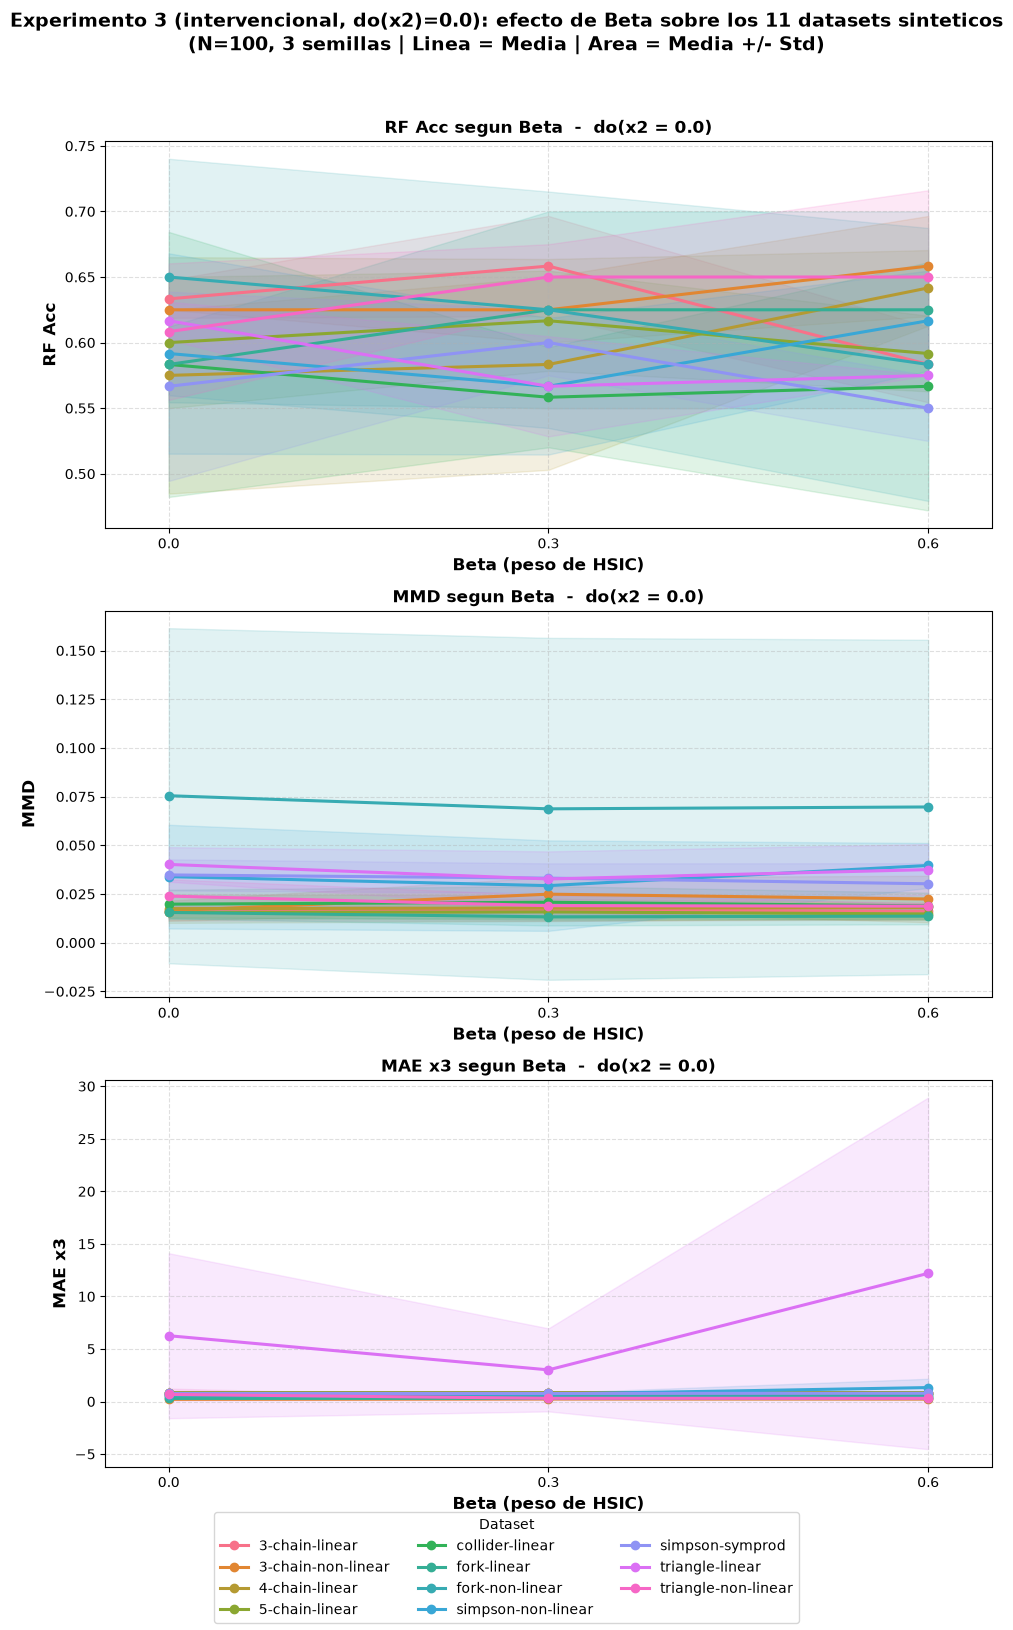

In [7]:
# PASO 7: una grafica por metrica (RF Acc, MMD, MAE x3) bajo do(x2=0). Eje X = beta, una curva por
# dataset, linea = media sobre las 3 semillas y banda sombreada = media +/- desviacion tipica.
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print(f"VISUALIZACION INTERVENCIONAL do({NODO_INTERVENIDO}={VALOR_DO}): MEDIA Y DESVIACION TIPICA POR METRICA")
print("(Linea = Media sobre las 3 semillas | Area sombreada = Media +/- Std | Un color = un dataset)")
print("="*100 + "\n")

colores_ds = sns.color_palette("husl", len(datasets_evaluados))
paleta_ds = dict(zip(datasets_evaluados, colores_ds))

# Las 3 metricas se apilan en vertical: una fila por metrica.
fig, axes = plt.subplots(len(metricas_experimento), 1, figsize=(10, 5.5 * len(metricas_experimento)))
fig.suptitle(f'Experimento 3 (intervencional, do({NODO_INTERVENIDO})={VALOR_DO}): efecto de Beta sobre los 11 datasets sinteticos\n'
             f'(N={valores_N_experimento[0]}, {len(semillas_experimento)} semillas | Linea = Media | Area = Media +/- Std)',
             fontsize=14, fontweight='bold')

for ax, metrica in zip(axes, metricas_experimento):
    for dataset in datasets_evaluados:
        df_ds = df_resumen[df_resumen['Dataset'] == dataset].sort_values('Beta')
        x = df_ds['Beta'].values
        y_mean = df_ds[f'{metrica}_mean'].values
        y_std = np.nan_to_num(df_ds[f'{metrica}_std'].values)

        ax.plot(x, y_mean, marker='o', linewidth=2.2, markersize=6, color=paleta_ds[dataset], label=dataset)
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=paleta_ds[dataset])

    ax.set_xlabel('Beta (peso de HSIC)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'{metrica} segun Beta  -  do({NODO_INTERVENIDO} = {VALOR_DO})', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xticks(valores_beta_candidatos)
    ax.set_xlim(min(valores_beta_candidatos) - 0.05, max(valores_beta_candidatos) + 0.05)

# Una unica leyenda compartida para los 11 datasets, debajo de la figura.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10, frameon=True, title='Dataset')
plt.tight_layout(rect=[0, 0.06, 1, 0.96])

if not os.path.exists('plots'):
    os.makedirs('plots')
ruta_plot = os.path.join('plots', 'bandplot_datasets_intervencional.png')
plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
print(f"Grafica guardada: {ruta_plot}\n")
plt.show()

In [8]:
# PASO 8: tabla final por beta. Filas = las 3 metricas, columnas = mean y std, agregando los
# 11 datasets x 3 semillas (33 runs por beta). Es la tabla que se comparara contra otros modelos.
print("\n" + "="*100)
print(f"TABLA FINAL INTERVENCIONAL do({NODO_INTERVENIDO}={VALOR_DO}): MEDIA Y DESVIACION TIPICA POR BETA "
      f"({len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas)")
print("="*100)

registros_finales = []
for beta_val in valores_beta_candidatos:
    df_beta = df_final[np.isclose(df_final['Beta'], beta_val)]
    tabla_beta = pd.DataFrame(
        {'mean': [df_beta[m].mean() for m in metricas_experimento],
         'std': [df_beta[m].std() for m in metricas_experimento]},
        index=metricas_experimento
    ).round(5)

    print(f"\n{'-'*60}\nBeta = {beta_val}  (Alpha = {round(1.0 - beta_val, 2)}, n_runs = {len(df_beta)})\n{'-'*60}")
    display(tabla_beta)

    for metrica in metricas_experimento:
        registros_finales.append({
            'Beta': beta_val,
            'Metrica': metrica,
            'mean': round(float(df_beta[metrica].mean()), 5),
            'std': round(float(df_beta[metrica].std()), 5)
        })

df_final_resumen = pd.DataFrame(registros_finales)
ruta_final = os.path.join("tablas", "resumen_final_por_beta_intervencional.csv")
df_final_resumen.to_csv(ruta_final, index=False)
print(f"\nTabla final guardada en: {ruta_final}")


TABLA FINAL INTERVENCIONAL do(x2=0.0): MEDIA Y DESVIACION TIPICA POR BETA (11 datasets x 3 semillas)

------------------------------------------------------------
Beta = 0.0  (Alpha = 1.0, n_runs = 33)
------------------------------------------------------------


,mean,std
RF Acc,0.60303,0.05821
MMD,0.02805,0.02895
MAE x3,1.14349,2.57239



------------------------------------------------------------
Beta = 0.3  (Alpha = 0.7, n_runs = 33)
------------------------------------------------------------


,mean,std
RF Acc,0.60682,0.05494
MMD,0.02656,0.02787
MAE x3,0.80652,1.23715



------------------------------------------------------------
Beta = 0.6  (Alpha = 0.4, n_runs = 33)
------------------------------------------------------------


,mean,std
RF Acc,0.60379,0.05900
MMD,0.02723,0.02765
MAE x3,1.69711,5.38563



Tabla final guardada en: tablas\resumen_final_por_beta_intervencional.csv



VISUALIZACION DE LA TABLA FINAL INTERVENCIONAL: MEDIA +/- STD AGREGADA POR BETA
(Linea = Media | Area sombreada = Media +/- Std | un panel por metrica)

Grafica guardada: plots\bandplot_resumen_final_por_beta_intervencional.png



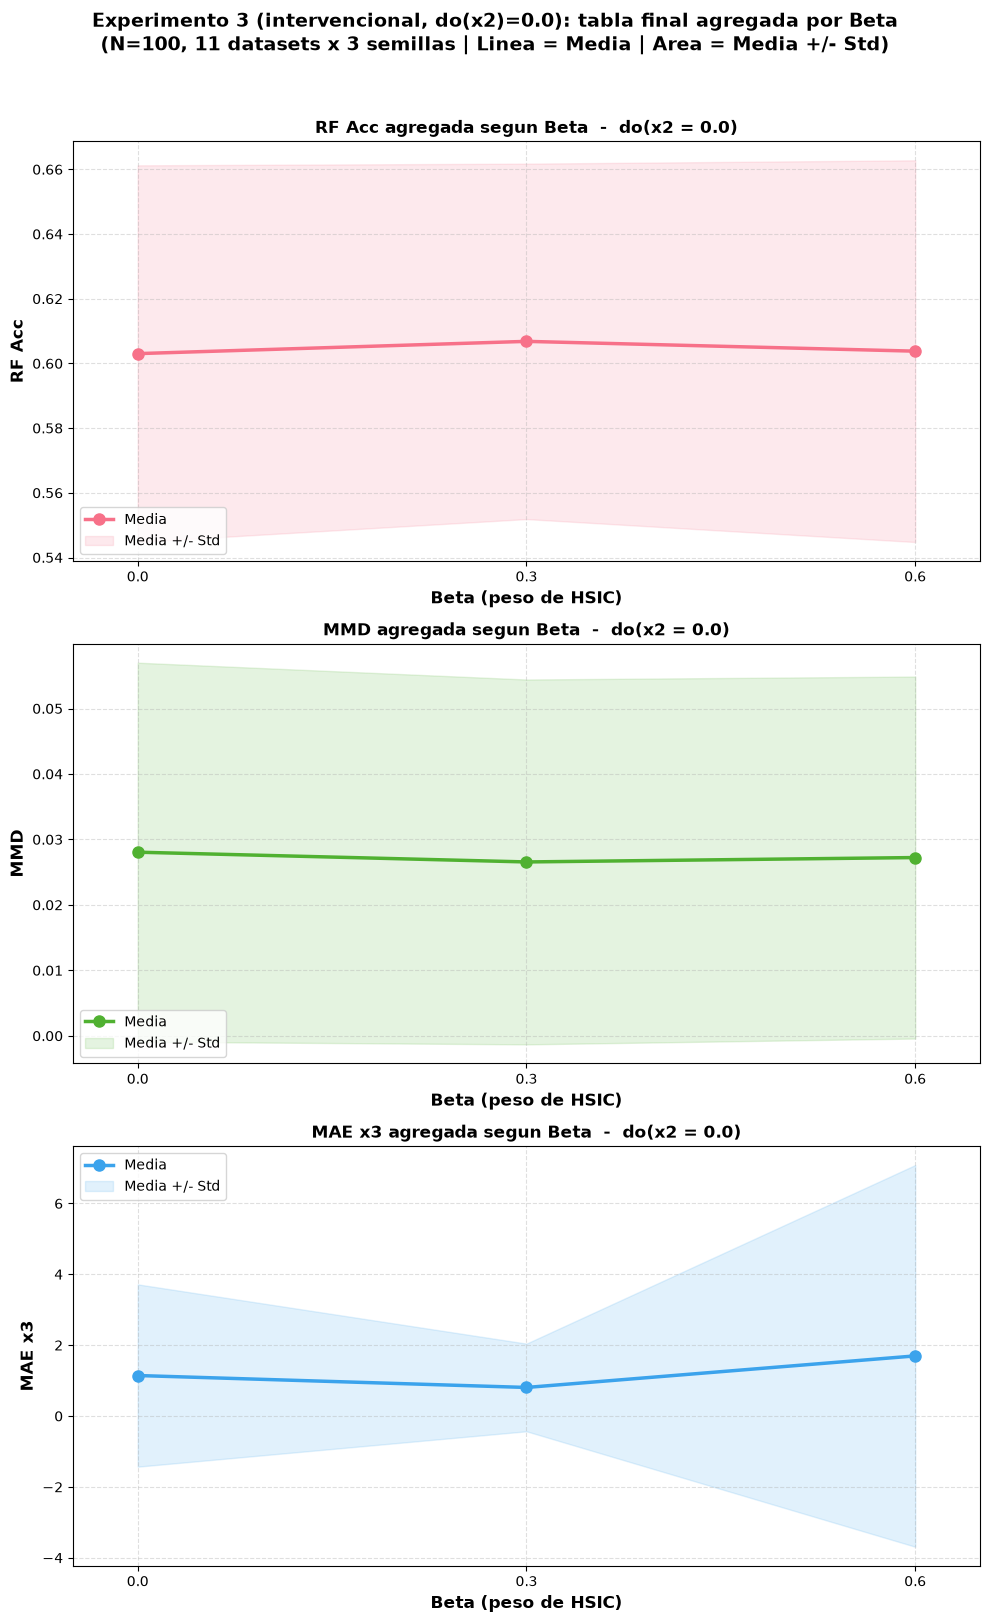

In [9]:
# PASO 9: la tabla final del PASO 8 en forma de grafica. Eje X = beta, linea = media agregada sobre
# los 11 datasets x 3 semillas y banda sombreada = media +/- desviacion tipica.
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACION DE LA TABLA FINAL INTERVENCIONAL: MEDIA +/- STD AGREGADA POR BETA")
print("(Linea = Media | Area sombreada = Media +/- Std | un panel por metrica)")
print("="*100 + "\n")

colores_metrica = dict(zip(metricas_experimento, sns.color_palette("husl", len(metricas_experimento))))

# Las 3 metricas se apilan en vertical: una fila por metrica.
fig, axes = plt.subplots(len(metricas_experimento), 1, figsize=(10, 5.5 * len(metricas_experimento)))
fig.suptitle('Experimento 3 (intervencional, do(x2)=0.0): tabla final agregada por Beta\n'
             f'(N={valores_N_experimento[0]}, {len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas | Linea = Media | Area = Media +/- Std)',
             fontsize=14, fontweight='bold')

for ax, metrica in zip(axes, metricas_experimento):
    df_m = df_final_resumen[df_final_resumen['Metrica'] == metrica].sort_values('Beta')
    x = df_m['Beta'].values
    y_mean = df_m['mean'].values
    y_std = np.nan_to_num(df_m['std'].values)
    color = colores_metrica[metrica]

    ax.plot(x, y_mean, marker='o', linewidth=2.5, markersize=8, color=color, label='Media')
    ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color, label='Media +/- Std')

    ax.set_xlabel('Beta (peso de HSIC)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'{metrica} agregada segun Beta  -  do({NODO_INTERVENIDO} = {VALOR_DO})', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xticks(valores_beta_candidatos)
    ax.set_xlim(min(valores_beta_candidatos) - 0.05, max(valores_beta_candidatos) + 0.05)
    ax.legend(loc='best', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])

if not os.path.exists('plots'):
    os.makedirs('plots')
ruta_plot_final = os.path.join('plots', 'bandplot_resumen_final_por_beta_intervencional.png')
plt.savefig(ruta_plot_final, dpi=300, bbox_inches='tight')
print(f"Grafica guardada: {ruta_plot_final}\n")
plt.show()